In [2]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

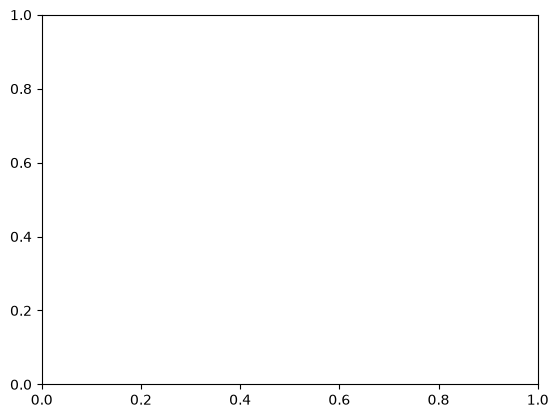

In [6]:
fig, ax = plt.subplots()

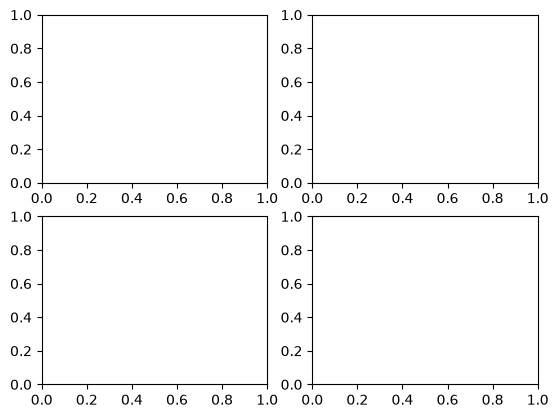

In [9]:
fig, ax = plt.subplots(2, 2)

<Axes: xlabel='job_title_short'>

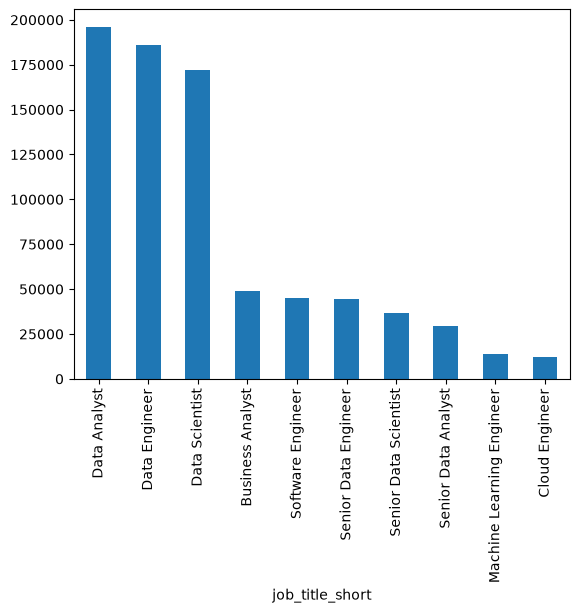

In [ ]:
fig, ax = plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar', ax = ax)

<Axes: xlabel='job_schedule_type'>

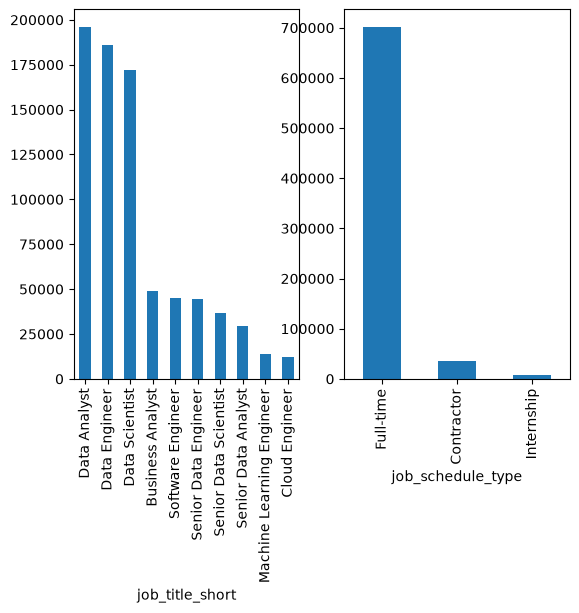

In [26]:
# fig: the entire figure/canvas
# ax: the axes

fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind = 'bar', ax = ax[0])

df['job_schedule_type'].value_counts().head(3).plot(kind = 'bar', ax = ax[1])

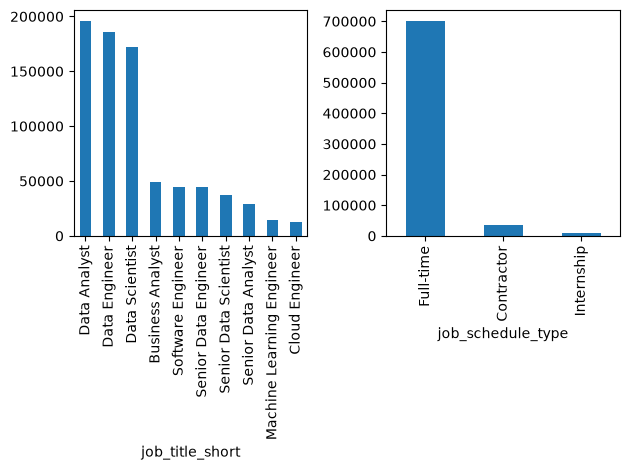

In [28]:
# Perform some formatting over the graph generated above

fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind = 'bar', ax = ax[0])

df['job_schedule_type'].value_counts().head(3).plot(kind = 'bar', ax = ax[1])

fig.tight_layout()

## Example - Counts of Top Skills in Job Postings

In [29]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


0 Data Scientist
1 Data Engineer
2 Data Analyst


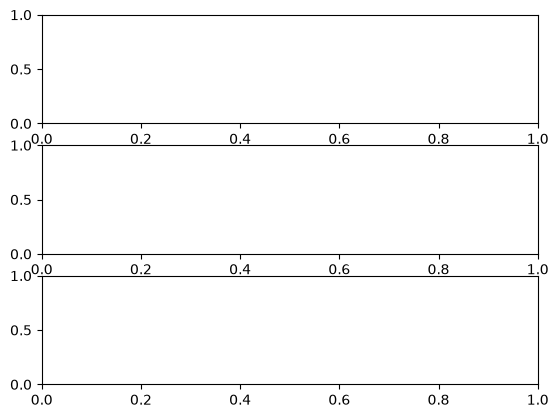

In [31]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
    print (i, job_title)

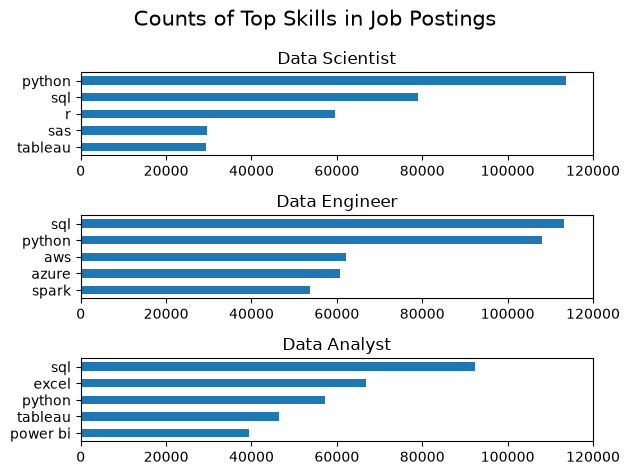

In [58]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_count', ax=ax[i], title = job_title)
    # ax[i].legend().remove()
    ax[i].legend().set_visible(False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 120000)
    # df_plot.set_index('job_skills')['skill_count'].plot(kind = 'barh', ax=ax[i])

fig.suptitle('Counts of Top Skills in Job Postings', fontsize = 15)
fig.tight_layout()

In [37]:
df_skills_count.dtypes

job_skills           str
job_title_short      str
skill_count        int64
dtype: object